# Book Graphics 3
- Game Trees Lets Go

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
from pathlib import Path as FilePath
from matplotlib.path import Path
from matplotlib.markers import MarkerStyle
from matplotlib.patches import FancyBboxPatch, Circle

CHILL_BROWN="#948979"
FRESH_TAN="#f4ebd9"
ORANGE='#eb8423'
LT_BLUE='#5badb6'
GREEN='#419c52'
RED='#d73b2f'
PINK='#ed5e78'

DATA = FilePath("/Users/stephen/ai_book_vol_2/chapters/08-reinforcement-learning/data")  # Chapter data lives next to the notebook

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list("blue_orange", [LT_BLUE, ORANGE], N=256)

In [2]:
HACKIN_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/rl_1/hackin'
SAVE_DIR = '/Volumes/hot_1/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/8_reinforcement_learning/graphics'

# HACKIN_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/rl_1/hackin'
# SAVE_DIR = '/Users/stephen/Library/CloudStorage/Dropbox-Stephencwelch/welch_labs/ai_book_vol_2/2_reinforcement_learning/graphics/'

In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

In [4]:
def style_ax(ax, color=CHILL_BROWN):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both')
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

def style_cbar(cbar, color=CHILL_BROWN):
    cbar.outline.set_edgecolor(color)
    cbar.ax.tick_params(colors=color, which='both')
    cbar.ax.yaxis.label.set_color(color)
    cbar.ax.xaxis.label.set_color(color)
    cbar.ax.title.set_color(color)

In [5]:
def arrow_path(direction=1, shaft_w=0.28, head_w=0.9, head_len=0.9, total_len=2.0):
    hl = head_len; sw = shaft_w/2; hw = head_w/2; L = total_len/2
    verts = np.array([
        (-L,  sw), (L-hl,  sw), (L-hl,  hw), (L, 0),
        (L-hl, -hw), (L-hl, -sw), (-L, -sw), (-L, sw),
    ]) * direction   # direction=-1 mirrors -> left arrow
    codes = [Path.MOVETO] + [Path.LINETO]*6 + [Path.CLOSEPOLY]
    return Path(verts, codes)

RIGHT_ARROW = MarkerStyle(arrow_path(+1))
LEFT_ARROW  = MarkerStyle(arrow_path(-1))

CART_W, CART_H, POLE_LEN, WHEEL_R = 0.5, 0.26, 1.0, 0.09
X_LIM = (-2.4, 2.4)

def draw_cartpole(ax, cart_x, pole_theta, action=None, y0=0.0,
                  setup_axes=True, track=True, arrow_size=420, arrow_dy=-0.32, stroke_color='k', fill_color='w'):
    """Draw one cart-pole state with its track baseline at y=y0."""
    if setup_axes:
        ax.set_xlim(*X_LIM); ax.set_ylim(y0-0.55, y0+1.75)
        ax.set_aspect('equal'); ax.axis('off')
    if track:
        ax.plot(X_LIM, [y0, y0], color=CHILL_BROWN, lw=1.5, zorder=1)
    cart_y = y0 + WHEEL_R*2
    for dx in (-CART_W*0.3, CART_W*0.3):
        ax.add_patch(Circle((cart_x+dx, y0+WHEEL_R), WHEEL_R, color=stroke_color, zorder=3))
    ax.add_patch(FancyBboxPatch((cart_x-CART_W/2, cart_y), CART_W, CART_H,
                 boxstyle="round,pad=0.02,rounding_size=0.05",
                 fc=fill_color, ec=stroke_color, lw=2.0, zorder=4))
    px, py = cart_x, cart_y + CART_H
    ax.plot([px, px + POLE_LEN*np.sin(pole_theta)],
            [py, py + POLE_LEN*np.cos(pole_theta)],
            color=stroke_color, lw=3, solid_capstyle='round', zorder=5)
    ax.add_patch(Circle((px, py), 0.07, color=stroke_color, zorder=6))
    if action is not None:   # needs RIGHT_ARROW / LEFT_ARROW defined
        ax.scatter([cart_x], [y0+arrow_dy],
                   marker=(RIGHT_ARROW if action==1 else LEFT_ARROW), s=arrow_size,
                   color=(YELLOW if action==1 else BLUE), linewidths=0, zorder=5)


def episode_frame_indices(n_steps, n_plots):
    """Evenly spaced step indices, always including the first and last step."""
    return np.unique(np.round(np.linspace(0, n_steps-1, n_plots)).astype(int))


def draw_episode(cart_xs, pole_thetas, n_plots, actions=None, spacing=1.6,
                 ax=None, fig_width=3.0, show_actions=False, label_steps=False,
                 pad_top=1.75, pad_bottom=0.55, top_down=True, **cartpole_kwargs):
    """
    Stack n_plots cart-pole states vertically in a single axis.

    spacing   : vertical distance between track baselines, in data units
                (the cart+pole is ~1.4 tall, so spacing < 1.4 will overlap).
    top_down  : first step at the top (True) or bottom (False).
    Returns fig, ax, idx (the step indices drawn), ys (baseline y of each frame).
    """
    cart_xs, pole_thetas = np.asarray(cart_xs), np.asarray(pole_thetas)
    idx = episode_frame_indices(len(cart_xs), n_plots)
    ys = -spacing*np.arange(len(idx)) if top_down else spacing*np.arange(len(idx))

    if ax is None:
        x_range = X_LIM[1]-X_LIM[0]
        y_range = spacing*(len(idx)-1) + pad_top + pad_bottom
        fig = plt.figure(figsize=(fig_width, fig_width*y_range/x_range))
        ax = fig.add_subplot(111)
    else:
        fig = ax.figure

    for t, y0 in zip(idx, ys):
        a = actions[t] if (show_actions and actions is not None) else None
        draw_cartpole(ax, cart_xs[t], pole_thetas[t], action=a, y0=y0,
                      setup_axes=False, **cartpole_kwargs)
        if label_steps:
            ax.text(X_LIM[0]-0.15, y0+0.1, f't={t}', ha='right', va='bottom',
                    color=CHILL_BROWN, fontsize=8)

    ax.set_xlim(*X_LIM)
    ax.set_ylim(ys.min()-pad_bottom, ys.max()+pad_top)
    ax.set_aspect('equal'); ax.axis('off')
    return fig, ax, idx, ys

In [6]:
with open(DATA / "sw_cartpole_game.json") as f: 
    data = json.load(f)

VEL_SCALE = 10   # divide velocities by 10 -> feature scales comparable, ~isotropic parameter space
obs = torch.tensor(data["episodes"][0]["observations"]) 
X = obs[:, 2:4] * 180/np.pi # Here we'll just use pole angle and pole angular velocity, and use degrees
X[:,1] = X[:,1] / VEL_SCALE # Scale pole angular velocity
y = torch.tensor(data['episodes'][0]['actions'])

In [7]:
X.shape, y.shape #This game is 66 steps long

(torch.Size([66, 2]), torch.Size([66]))

(-15.0, 15.0)

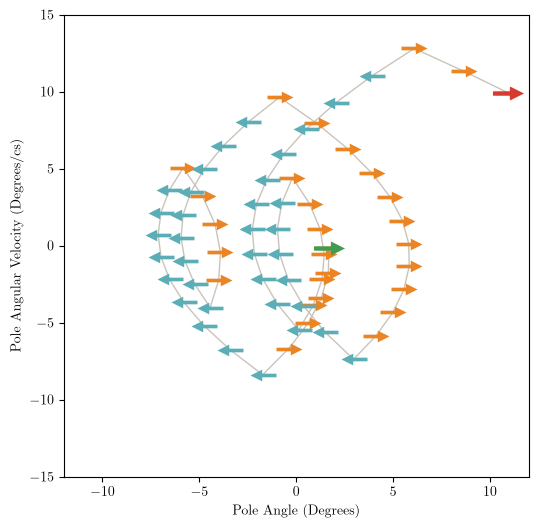

In [8]:
fig=plt.figure(0, (6,6))
ax=fig.add_subplot(111)

m = (y == 1)
plt.plot(X[:,0], X[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
ax.scatter(X[m, 0],  X[m, 1],  marker=RIGHT_ARROW, s=350, color=ORANGE, alpha=1.0, linewidths=0)
ax.scatter(X[~m, 0], X[~m, 1], marker=LEFT_ARROW,  s=350, color=LT_BLUE,   alpha=1.0, linewidths=0)
ax.scatter(X[0, 0],  X[0, 1],  marker= RIGHT_ARROW if y[0]==1 else LEFT_ARROW, s=500, color=GREEN, alpha=1.0, linewidths=0) #First step green
ax.scatter(X[-1, 0],  X[-1, 1],  marker= RIGHT_ARROW if y[-1]==1 else LEFT_ARROW, s=500, color=RED, alpha=1.0, linewidths=0) #Last step red
plt.xlabel('Pole Angle (Degrees)'); plt.ylabel('Pole Angular Velocity (Degrees/cs)')
plt.xlim([-12, 12]); plt.ylim([-15, 15])


In [9]:
class Pi(nn.Module):
    """Two-parameter policy: logit = theta1 * pole_angle + theta2 * pole_ang_velocity."""
    def __init__(self):
        super().__init__()
        self.theta = nn.Parameter(torch.zeros(2))  # [theta1, theta2] -> uniform random policy at init

    def forward(self, x):
        logit = x @ self.theta.to(x.dtype)         # compute at the precision of the input; we'll need double precision later
        return torch.sigmoid(logit)

In [10]:
def to_features(state):
    """Gymnasium state [x, x_dot, angle, ang_vel] (radians) -> the 2 features our agent trained on."""
    f = torch.tensor(state[2:4], dtype=torch.float32) * 180/np.pi   # angle, angular velocity in degrees
    f[1] = f[1] / VEL_SCALE
    return f

def run_episode(agent, seed, max_steps=500):   # CartPole-v1 truncates at 500 steps
    env = gym.make("CartPole-v1")
    state, _ = env.reset(seed=seed)
    X_ep, y_ep = [], []
    for t in range(max_steps):
        with torch.no_grad():
            features = to_features(state)
            action = int(agent(features) >= 0.5)   # yhat >= 0.5 -> push right
        X_ep.append(features); y_ep.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated: break
    return torch.stack(X_ep), torch.tensor(y_ep)

def plot_state_space(ax, X_ep, y_ep, s=120):   # Helper: same picture as our human data plot
    m = (y_ep == 1)
    ax.plot(X_ep[:,0], X_ep[:,1], color=CHILL_BROWN, lw=1, alpha=0.5, zorder=-10)
    ax.scatter(X_ep[m, 0],  X_ep[m, 1],  marker=RIGHT_ARROW, s=s, color=ORANGE,  linewidths=0)
    ax.scatter(X_ep[~m, 0], X_ep[~m, 1], marker=LEFT_ARROW,  s=s, color=LT_BLUE, linewidths=0)
    ax.scatter(X_ep[0, 0],  X_ep[0, 1],  marker=RIGHT_ARROW if y_ep[0]==1  else LEFT_ARROW, s=s*1.3, color='g', linewidths=0)
    ax.scatter(X_ep[-1, 0], X_ep[-1, 1], marker=RIGHT_ARROW if y_ep[-1]==1 else LEFT_ARROW, s=s*1.3, color='r', linewidths=0)
    ax.set_xlim(*ANG_LIM); ax.set_ylim(*VEL_LIM)

In [11]:
def run_episode_stochastic(agent, env_seed, policy_seed, max_steps=500):
    """Same as run_episode, but the agent pushes right with probability yhat instead of whenever yhat >= 0.5."""
    env = gym.make("CartPole-v1")
    state, _ = env.reset(seed=env_seed)
    rng = np.random.default_rng(policy_seed)             # policy randomness, independent of the starting state
    X_ep, y_ep = [], []
    for t in range(max_steps):
        with torch.no_grad():
            features = to_features(state)
            action = int(rng.random() < agent(features))   # push right with probability yhat
        X_ep.append(features); y_ep.append(action)
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated: break
    return torch.stack(X_ep), torch.tensor(y_ep)

In [12]:
N_ROLLOUTS = 1000 #I like 1000 moar b/c we want to turn frequencies into probs!
samples = [0, 15, 234, 576] #We'll use these specific examples later
colors = ['g', ORANGE, 'y', LT_BLUE]

In [13]:
theta_0 = torch.tensor([-0.5, 0.0])
agent = Pi()
with torch.no_grad(): agent.theta[:] = theta_0

rollouts = [run_episode_stochastic(agent, env_seed=0, policy_seed=i) for i in tqdm(range(N_ROLLOUTS))]   # same start every time
lengths = np.array([len(y_ep) for _, y_ep in rollouts])
print(f'episode length: mean {lengths.mean():.1f}  min {lengths.min()}  max {lengths.max()}')

100%|█████████████████████████████████| 1000/1000 [00:00<00:00, 3217.17it/s]

episode length: mean 9.9  min 8  max 29


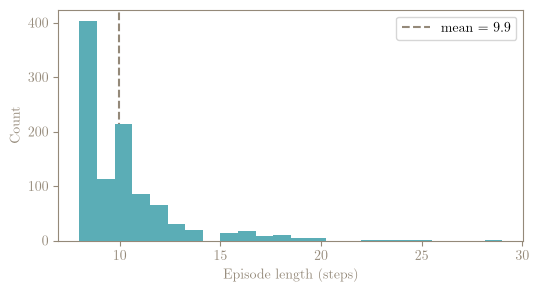

In [14]:
fig=plt.figure(0, (6, 3))
ax=fig.add_subplot(111)
plt.hist(lengths, bins=24, color=LT_BLUE, zorder=3)
plt.axvline(lengths.mean(), color=CHILL_BROWN, ls='--', label=f'mean = {lengths.mean():.1f}')
plt.xlabel('Episode length (steps)'); plt.ylabel('Count'); plt.legend()
# plt.title(f'{N_EPISODES} episodes, trained agent')
style_ax(ax)
for artist in ax.get_children():
    artist.set_clip_on(False)
# plt.savefig(SAVE_DIR + '/rl_hist_1c.svg', bbox_inches='tight')

In [26]:
from collections import Counter

action_str = lambda a_ep: ''.join('R' if a == 1 else 'L' for a in a_ep.tolist())
counts = Counter(action_str(a_ep) for _, a_ep in rollouts)

print(f'{len(counts)} distinct rollouts out of {N_ROLLOUTS}')
for seq, n in counts.most_common(200):
    print(f'{n:4d}  ({n/N_ROLLOUTS:.3f})  {len(seq):3d} steps  {seq}')

150 distinct rollouts out of 1000
 389  (0.389)    8 steps  RRRRRRRR
  81  (0.081)   10 steps  RLRRRRRRRR
  63  (0.063)   10 steps  RRLRRRRRRR
  55  (0.055)    9 steps  RRRLRRRRR
  50  (0.050)   10 steps  LRRRRRRRRR
  34  (0.034)    9 steps  RRRRLRRRR
  18  (0.018)   11 steps  LRRRLRRRRRR
  17  (0.017)    9 steps  RRRRRLRRR
  16  (0.016)   12 steps  LRLRRRRRRRRR
  15  (0.015)   12 steps  LRRLRRRRRRRR
  12  (0.012)   11 steps  RLRRLRRRRRR
  11  (0.011)   11 steps  RLRLRRRRRRR
  10  (0.010)   12 steps  RLLRRRRRRRRR
   9  (0.009)    8 steps  RRRRRRLR
   9  (0.009)   11 steps  RRLLRRRRRRR
   9  (0.009)   12 steps  LLRRRRRRRRRR
   7  (0.007)   11 steps  LRRRRLRRRRR
   6  (0.006)    8 steps  RRRRRRRL
   6  (0.006)   11 steps  LRRRRRLRRRR
   6  (0.006)   10 steps  RRRLLRRRRR
   5  (0.005)   11 steps  RRLRRLRRRRR
   5  (0.005)   11 steps  RLRRRLRRRRR
   5  (0.005)   11 steps  RRLRLRRRRRR
   4  (0.004)   14 steps  RLLLRRRRRRRRRR
   4  (0.004)   13 steps  RLLRRLRRRRRRR
   3  (0.003)    9 steps  

In [25]:
len(counts)

150

Text(0.5, 1.0, 'Most common rollouts, 1000 samples')

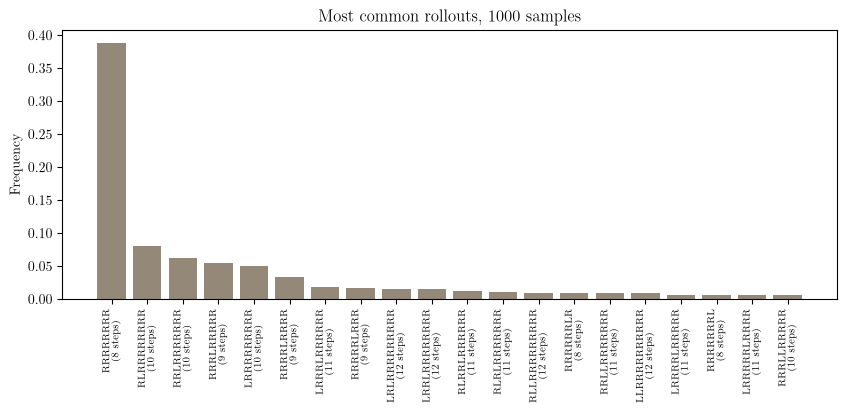

In [16]:
top = counts.most_common(20)
fig = plt.figure(0, (10, 3.5)); ax = fig.add_subplot(111)
ax.bar(range(len(top)), [n / N_ROLLOUTS for _, n in top], color=CHILL_BROWN)
ax.set_xticks(range(len(top))); ax.set_xticklabels([f'{s}\n({len(s)} steps)' for s, _ in top], rotation=90, fontsize=7, family='monospace')
ax.set_ylabel('Frequency'); ax.set_title(f'Most common rollouts, {N_ROLLOUTS} samples')

In [19]:
# --- Game tree: building ---------------------------------------------------
class Node:
    def __init__(self, action=None, prob=1.0, state=None, terminal=False, depth=0):
        self.action = action        # 0 = left, 1 = right, None = root
        self.prob = prob            # P(action | parent state)
        self.state = state
        self.terminal = terminal
        self.depth = depth
        self.children = {}          # {0: Node, 1: Node}
        self.count = 0              # sampled rollouts through this node (trie version)
        self.x = self.y = 0.0

    def walk(self):
        yield self
        for c in self.children.values():
            yield from c.walk()

    def leaves(self):
        return [self] if not self.children else sum((c.leaves() for c in self.children.values()), [])


class CartPoleStepper:
    """Deterministic CartPole-v1 stepping from an arbitrary state (same dynamics as our rollouts)."""
    def __init__(self, seed=0):
        self.env = gym.make("CartPole-v1")
        self.s0, _ = self.env.reset(seed=seed)
        self.u = self.env.unwrapped

    def step(self, state, action):
        self.u.state = np.array(state, dtype=np.float64)
        self.u.steps_beyond_terminated = None
        _, _, terminated, _, _ = self.env.step(int(action))
        return np.array(self.u.state, dtype=np.float64), bool(terminated)


def p_right(agent, state):
    with torch.no_grad():
        return float(agent(to_features(state)))


def build_full_tree(agent, depth, seed=0):
    """Every action sequence up to `depth` (2**depth leaves), with true policy probabilities."""
    sim = CartPoleStepper(seed)
    root = Node(state=sim.s0)
    def expand(node):
        if node.depth >= depth or node.terminal: return
        pr = p_right(agent, node.state)
        for a, p in ((1, pr), (0, 1 - pr)):            # right first -> drawn on top
            s, term = sim.step(node.state, a)
            node.children[a] = Node(a, p, s, term, node.depth + 1)
            expand(node.children[a])
    expand(root)
    return root


def build_trie(agent, action_seqs, counts=None, seed=0):
    """Tree containing only the given action strings ('RLRR...'), e.g. counts.most_common(20)."""
    sim = CartPoleStepper(seed)
    root = Node(state=sim.s0)
    for i, seq in enumerate(action_seqs):
        n = counts[i] if counts is not None else 1
        node = root; node.count += n
        for ch in seq:
            a = 1 if ch == 'R' else 0
            if a not in node.children:
                pr = p_right(agent, node.state)
                s, term = sim.step(node.state, a)
                node.children[a] = Node(a, pr if a == 1 else 1 - pr, s, term, node.depth + 1)
            node = node.children[a]; node.count += n
    return root


def layout(root, dx=40.0, dy=12.0):
    """Leaves evenly spaced dy pt apart, parents centered on children, depth d at x = d*dx."""
    y = [0.0]
    def place(node):
        node.x = node.depth * dx
        if not node.children:
            node.y = y[0]; y[0] -= dy
        else:
            kids = [node.children[a] for a in (1, 0) if a in node.children]
            for k in kids: place(k)
            node.y = np.mean([k.y for k in kids])
    place(root)
    return root

In [20]:
# --- Game tree: drawing ----------------------------------------------------
from matplotlib.patches import PathPatch, Rectangle, Polygon

TREE_STYLE = dict(
    node_r=2.7, lw=0.75, corner=1.6,            # pt; measured off the Illustrator sketch
    edge_color=CHILL_BROWN, node_fill='white',
    arrow_len=9.35, arrow_head_w=4.33, arrow_head_len=3.75, arrow_shaft_w=1.24,
    label_size=6, label_gap=2.0, knockout_pad=0.6,
)

def _draw_elbow(ax, parent, child, st):
    """child <- horizontal at child.y <- rounded corner <- vertical at parent.x <- parent."""
    r, nr = st['corner'], st['node_r']
    px, py, cx, cy = parent.x, parent.y, child.x, child.y
    sgn = np.sign(cy - py)
    verts = [(cx - nr, cy), (px + r, cy), (px, cy), (px, cy - sgn*r), (px, py + sgn*nr)]
    codes = [Path.MOVETO, Path.LINETO, Path.CURVE3, Path.CURVE3, Path.LINETO]
    ax.add_patch(PathPatch(Path(verts, codes), fc='none', ec=st['edge_color'], lw=st['lw'], zorder=1))

def _draw_arrow(ax, x, y, action, st, label=None):
    verts = arrow_path(+1 if action == 1 else -1, shaft_w=st['arrow_shaft_w'], head_w=st['arrow_head_w'],
                       head_len=st['arrow_head_len'], total_len=st['arrow_len']).vertices + (x, y)
    w = st['arrow_len'] + 2*st['knockout_pad']; h = st['arrow_head_w'] + 2*st['knockout_pad']
    ax.add_patch(Rectangle((x - w/2, y - h/2), w, h, fc='white', ec='none', zorder=2))   # knocks out the line
    ax.add_patch(Polygon(verts, closed=True, fc=ORANGE if action == 1 else LT_BLUE, ec='none', zorder=3))
    if label is not None:
        ax.text(x, y - h/2 - st['label_gap'], label, ha='center', va='top',
                fontsize=st['label_size'], color=st['edge_color'], zorder=3)

def render_tree(root, style=None, show_probs=True, prob_fmt='{:.2f}', label_max_depth=None, pad=6.0):
    """label_max_depth: only print probabilities on edges into nodes at depth <= this."""
    st = {**TREE_STYLE, **(style or {})}
    nodes = list(root.walk())
    xs = [n.x for n in nodes]; ys = [n.y for n in nodes]
    x0, x1 = min(xs) - pad, max(xs) + pad
    y0, y1 = min(ys) - pad - st['label_size'] - 8, max(ys) + pad
    fig = plt.figure(figsize=((x1 - x0)/72, (y1 - y0)/72))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_aspect('equal'); ax.axis('off')

    for n in nodes:
        for c in n.children.values():
            _draw_elbow(ax, n, c, st)
            lab = show_probs and (label_max_depth is None or c.depth <= label_max_depth)
            _draw_arrow(ax, (n.x + c.x)/2, c.y, c.action, st, label=prob_fmt.format(c.prob) if lab else None)
    for n in nodes:
        ax.add_patch(Circle((n.x, n.y), st['node_r'], fc=st['node_fill'], ec=st['edge_color'], lw=st['lw'], zorder=4))
    return fig, ax

def save_tree_svg(fig, path):
    with plt.rc_context({'svg.fonttype': 'none'}):     # editable text (only matters when usetex is off)
        fig.savefig(path, format='svg', bbox_inches='tight', pad_inches=0.02)

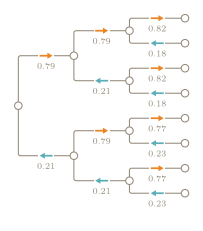

In [22]:
# root = layout(build_full_tree(agent, depth=3), dx=40, dy=16)   # dy=16 fits a label on every arrow
# fig, ax = render_tree(root)
# save_tree_svg(fig, SAVE_DIR + '/rl_game_tree_depth3.svg')

# # sketch-style: tight spacing, labels on first two levels only
# root = layout(build_full_tree(agent, depth=3), dx=40, dy=12)
# fig, ax = render_tree(root, label_max_depth=2)
# save_tree_svg(fig, SAVE_DIR + '/rl_game_tree_depth3_tight.svg')

root = layout(build_full_tree(agent, depth=3), dx=40, dy=18)
fig, ax = render_tree(root, style=dict(knockout_pad=1.2))   # no label_max_depth -> every level labelled
save_tree_svg(fig, SAVE_DIR + '/rl_game_tree_depth3.svg')

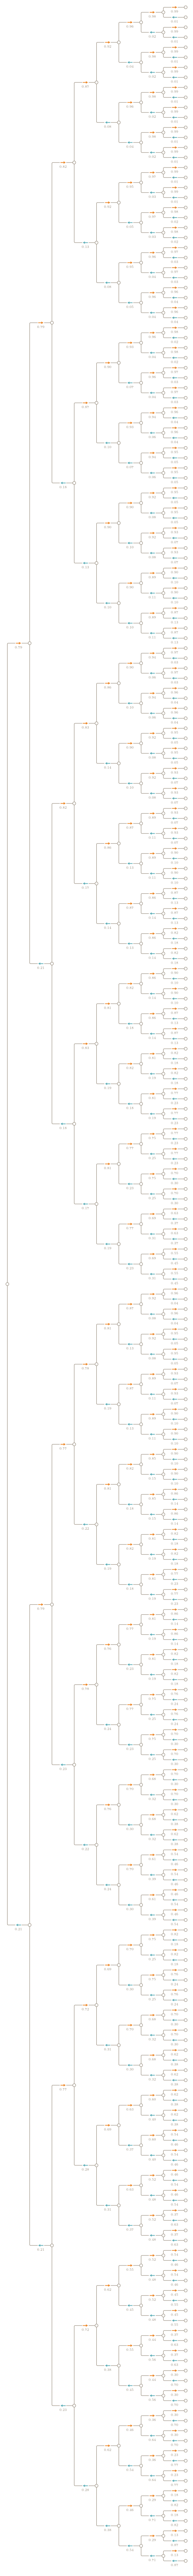

In [23]:
root = layout(build_full_tree(agent, depth=8), dx=40, dy=18)
fig, ax = render_tree(root, style=dict(knockout_pad=1.2))   # no label_max_depth -> every level labelled
save_tree_svg(fig, SAVE_DIR + '/rl_game_tree_depth8.svg')